**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Ari Jahaziel Rodríguez Cruz Abeyro
*   MATRÍCULA: A01840831

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [63]:
# Instalar las bibliotecas necesarias
!pip install ipykernel category_encoders
import warnings
warnings.filterwarnings('ignore')   # requerido: la libreta debe quedar libre de warnings


In [64]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [65]:
compu_df = pd.read_csv('computer_prices.csv')
compu_df.info()

# Conteo de columnas numéricas vs texto
numeric_cols = compu_df.select_dtypes(include='number').columns.tolist()
text_cols    = compu_df.select_dtypes(include='object').columns.tolist()

print(f"Columnas numéricas : {len(numeric_cols)}")
print(f"Columnas de texto  : {len(text_cols)}")

# Valores únicos por columna
print(compu_df.nunique().sort_values(ascending=False).to_string())

compu_df.drop(columns=['model', 'cpu_model'], inplace=True)
print(f"Forma del dataframe tras eliminar columnas: {compu_df.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  str    
 1   brand                100000 non-null  str    
 2   model                100000 non-null  str    
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  str    
 5   form_factor          100000 non-null  str    
 6   cpu_brand            100000 non-null  str    
 7   cpu_model            100000 non-null  str    
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  str    
 12  gpu_model            100000 non-null  str    
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb               100000 n

### Respuesta — Ejercicio 1

El dataset original contiene **15 columnas numéricas** (12 de tipo `int64`: `release_year`, `cpu_tier`, `cpu_cores`, `cpu_threads`, `gpu_tier`, `vram_gb`, `ram_gb`, `storage_gb`, `storage_drive_count`, `charger_watts`, `psu_watts`, `warranty_months`; y 3 de tipo `float64`: `bluetooth`, `weight_kg`, `price`) y **12 columnas de texto** (`device_type`, `brand`, `model`, `os`, `form_factor`, `cpu_brand`, `cpu_model`, `gpu_brand`, `gpu_model`, `storage_type`, `display_type`, `wifi`).

Se eliminan `model` y `cpu_model`:
- `model`: 99,036 valores únicos sobre 100,000 registros — prácticamente un identificador por fila, sin capacidad de generalización.
- `cpu_model`: 26,971 valores únicos; su información está representada de forma compacta en `cpu_tier` (gama), `cpu_cores` (núcleos) y `cpu_threads` (hilos).

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

### Contexto — Ejercicio 2

Antes de transformar variables es indispensable conocer la calidad del dato. La presencia de duplicados infla artificialmente el peso de ciertos registros en el entrenamiento; los valores faltantes requieren estrategia de imputación o eliminación. Las visualizaciones y las estadísticas descriptivas revelan la distribución individual de cada variable, detectan asimetrías y confirman que las frecuencias de categorías son razonables.

In [66]:
# Verificación de duplicados
n_dup = compu_df.duplicated().sum()
print(f"Filas duplicadas: {n_dup}")
if n_dup > 0:
    compu_df.drop_duplicates(inplace=True)
    print("Duplicados eliminados.")

# Verificación de valores faltantes
missing = compu_df.isnull().sum()
missing_pct = (missing / len(compu_df) * 100).round(2)
missing_report = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_report = missing_report[missing_report['count'] > 0]
if missing_report.empty:
    print("No hay valores faltantes.")
else:
    print(missing_report)

Filas duplicadas: 0
No hay valores faltantes.


In [67]:
# Estadísticas descriptivas — numéricas
print("=== Estadísticas descriptivas — Numéricas ===")
print(compu_df.select_dtypes(include='number').describe().T.to_string())

=== Estadísticas descriptivas — Numéricas ===
                        count         mean         std      min      25%      50%      75%       max
release_year         100000.0  2022.320850    2.025761  2018.00  2021.00  2023.00  2024.00   2025.00
cpu_tier             100000.0     3.153490    1.373175     1.00     2.00     3.00     4.00      6.00
cpu_cores            100000.0    10.515740    5.044092     4.00     6.00     8.00    14.00     28.00
cpu_threads          100000.0    19.372700    9.718426     4.00    12.00    16.00    24.00     56.00
gpu_tier             100000.0     2.991350    1.459643     1.00     2.00     3.00     4.00      6.00
vram_gb              100000.0     6.152180    3.964926     0.00     4.00     6.00     8.00     16.00
ram_gb               100000.0    39.706400   31.902684     8.00    16.00    32.00    64.00    144.00
storage_gb           100000.0   903.936000  774.243654   256.00   512.00   512.00  1024.00   4096.00
storage_drive_count  100000.0     1.524980   

In [68]:
# Tablas de frecuencia — categóricas
print("=== Tablas de frecuencia — Categóricas ===")
for col in compu_df.select_dtypes(include='object').columns:
    print(f"\n{'─'*40}")
    print(f"{col}:")
    print(compu_df[col].value_counts().to_string())

=== Tablas de frecuencia — Categóricas ===

────────────────────────────────────────
device_type:
device_type
Laptop     59844
Desktop    40156

────────────────────────────────────────
brand:
brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033

────────────────────────────────────────
os:
os
Windows     71817
macOS       18207
Linux        6109
ChromeOS     3867

────────────────────────────────────────
form_factor:
form_factor
Mainstream     17819
Gaming         16876
ATX            15597
Ultrabook      13236
Micro-ATX       8672
Full-Tower      7110
2-in-1          7049
SFF             5585
Workstation     4864
Mini-ITX        3192

────────────────────────────────────────
cpu_brand:
cpu_brand
Intel    52774
AMD      35311
Apple    11915

────────────────────────────────────────
gpu_brand:
gpu_brand
NVIDIA    54712
Apple     18922
AMD       15767
Inte

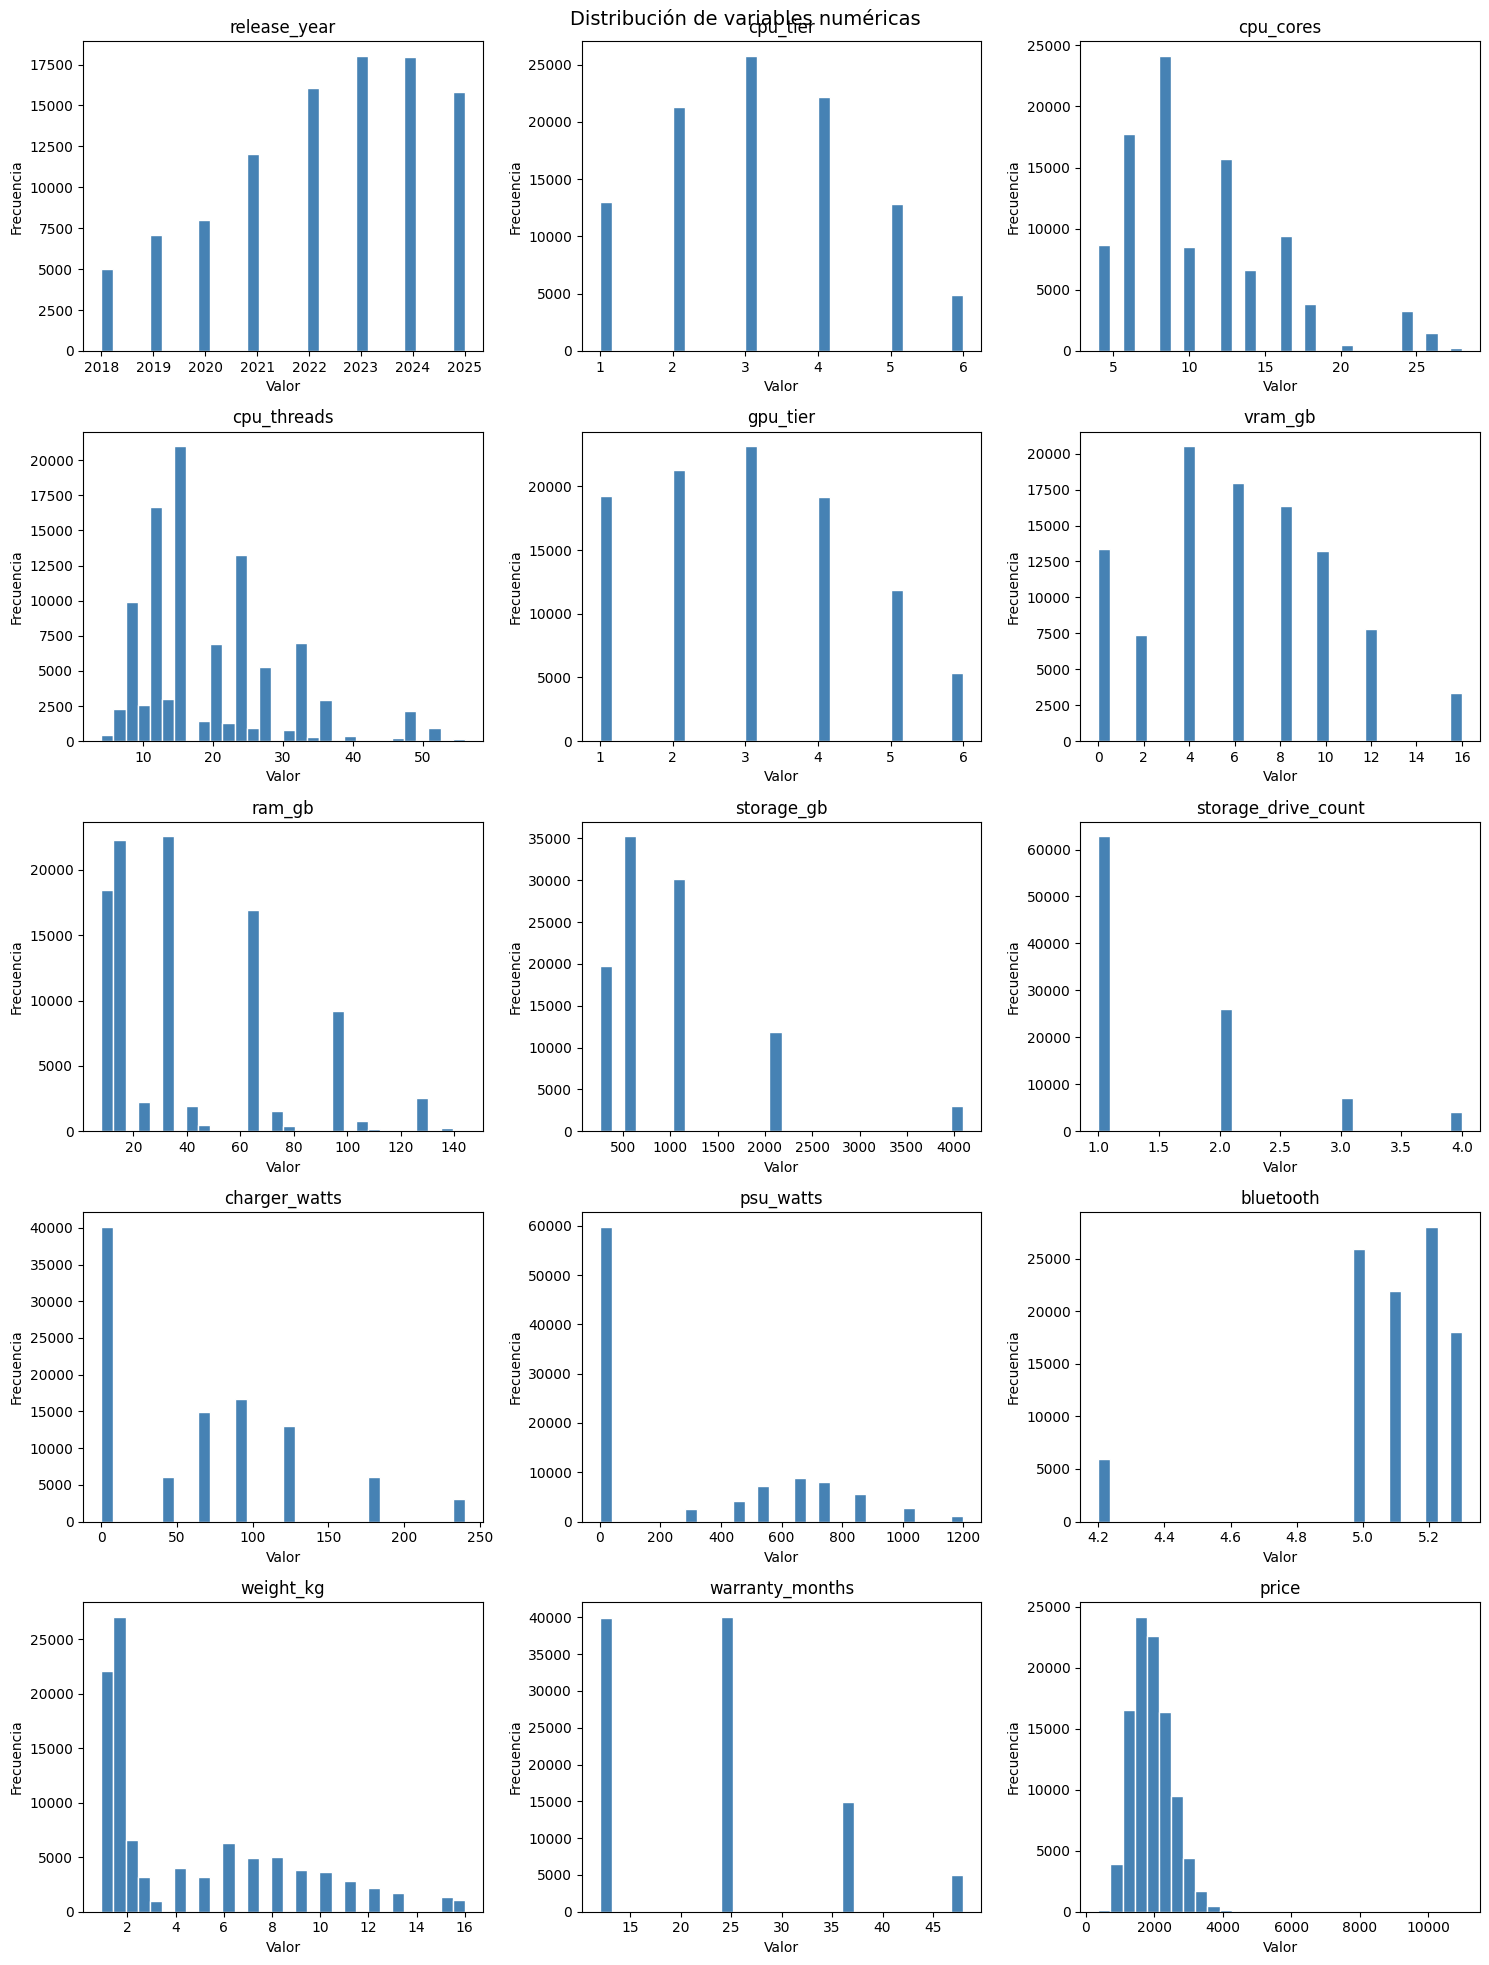

In [69]:
# Histogramas — variables numéricas
num_cols = compu_df.select_dtypes(include='number').columns
n = len(num_cols)
cols_per_row = 3
nrows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(nrows=nrows, ncols=cols_per_row, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(compu_df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

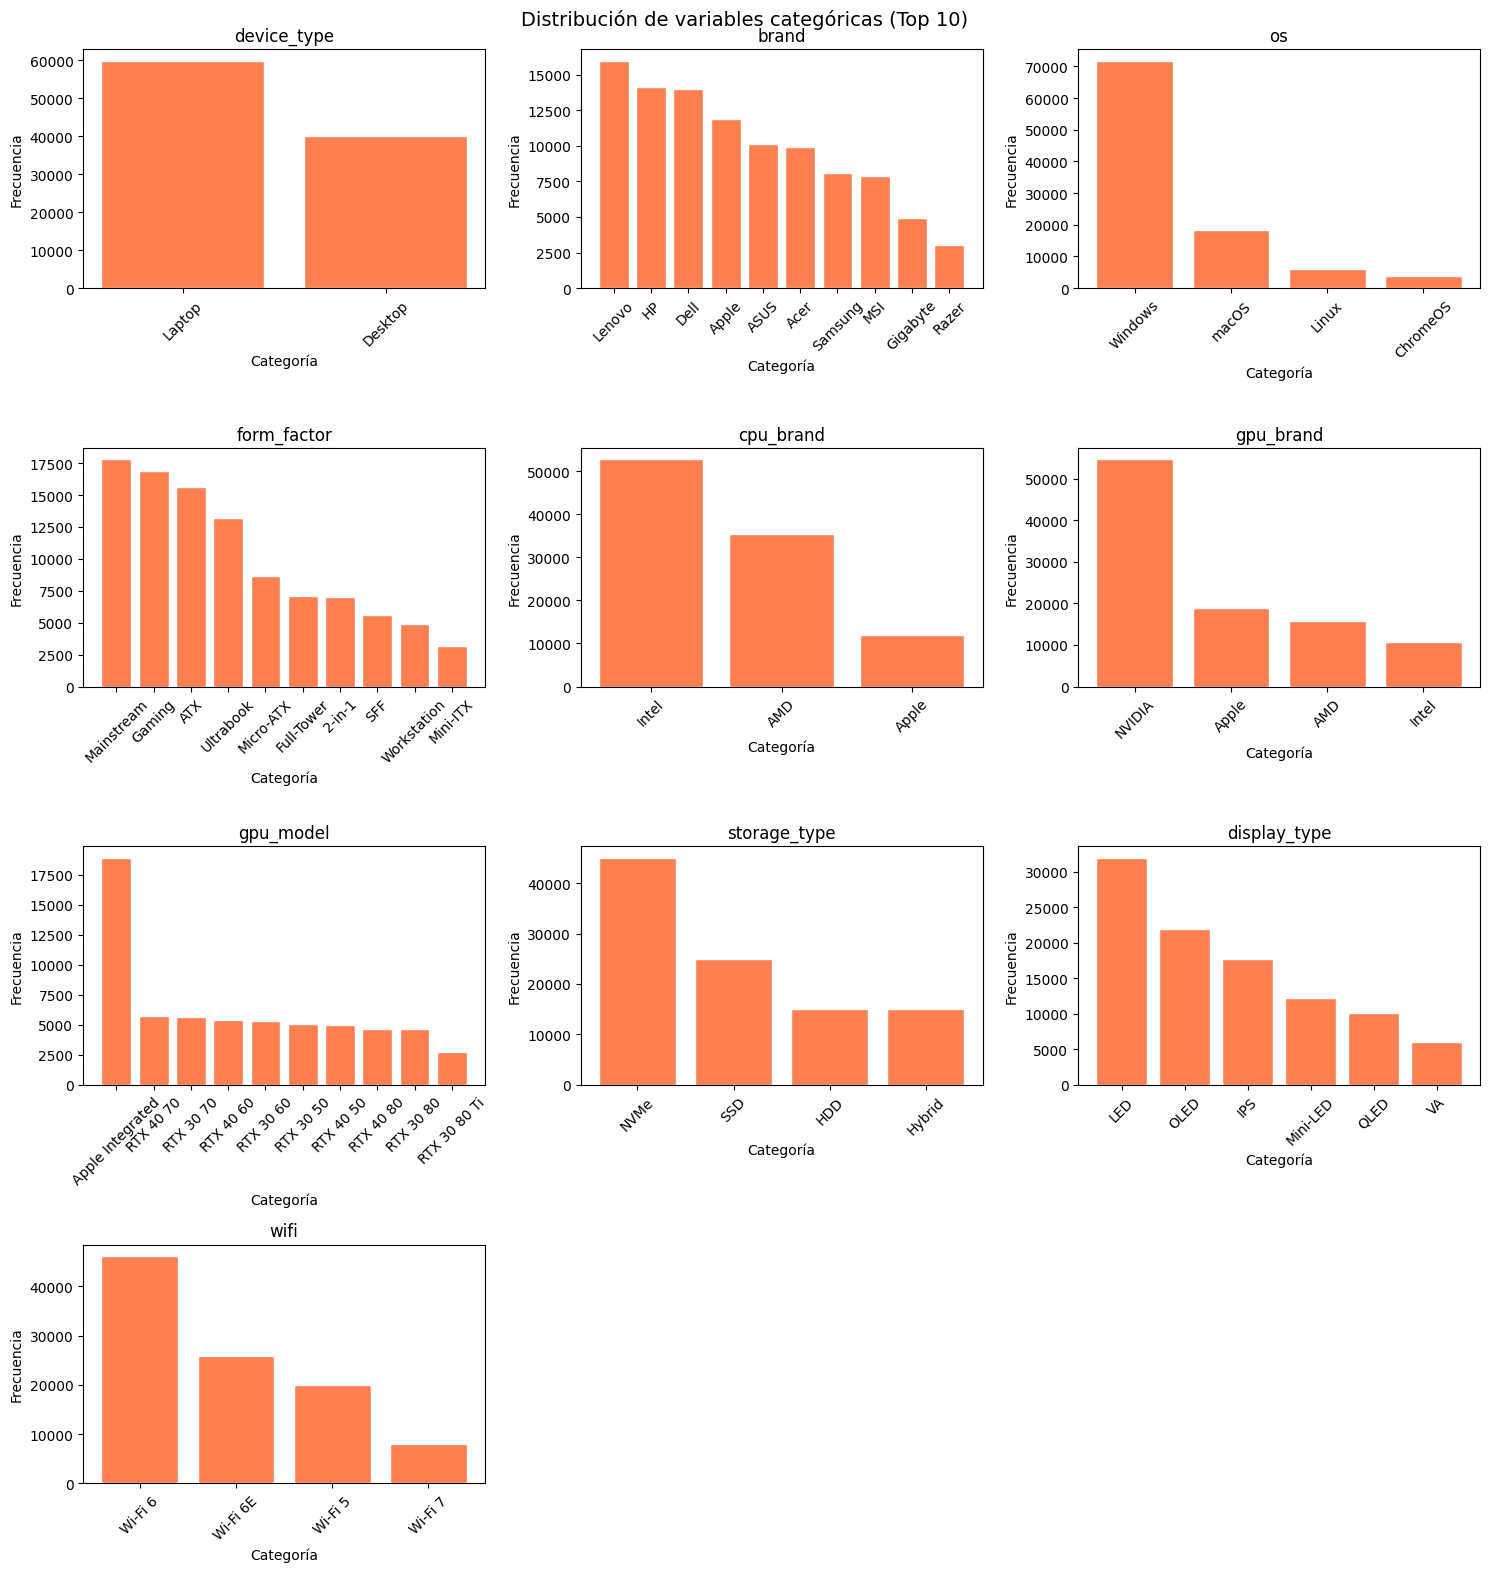

In [70]:
# Diagramas de barras — variables categóricas (top 10)
cat_cols = compu_df.select_dtypes(include='object').columns
nrows = (len(cat_cols) + 2) // 3

fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    top10 = compu_df[col].value_counts().head(10)
    axes[i].bar(top10.index, top10.values, color='coral', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribución de variables categóricas (Top 10)', fontsize=14)
plt.tight_layout()
plt.show()

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables, de las que se imprimieron, representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

### Contexto — Ejercicio 3

La correlación entre variables numéricas revela redundancias. Mantener variables altamente correlacionadas (|r| > 0.9) no mejora la predicción de precios pero incrementa la complejidad del modelo y genera multicolinealidad, lo que dificulta la interpretación de coeficientes y puede desestabilizar algoritmos de regresión.

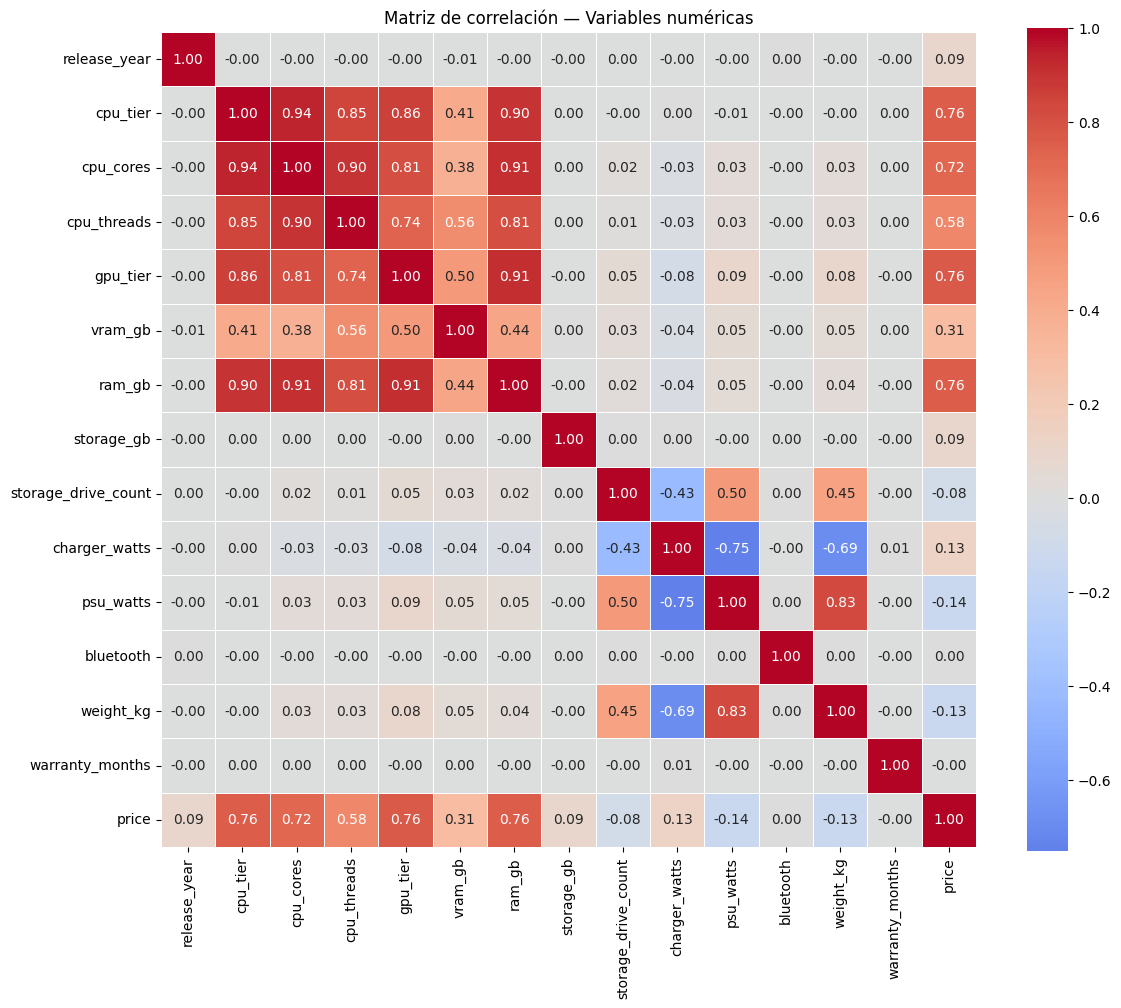

In [71]:
# Matriz de correlación y mapa de calor
corr_matrix = compu_df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de correlación — Variables numéricas')
plt.tight_layout()
plt.show()

In [72]:
# Identificar pares con correlación > 0.9
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > 0.9
]

print("Pares con correlación > 0.9:")
for v1, v2, r in high_corr_pairs:
    print(f"  {v1:20s} ↔  {v2:20s}   r = {r:.3f}")

Pares con correlación > 0.9:
  cpu_cores            ↔  cpu_tier               r = 0.937
  ram_gb               ↔  cpu_cores              r = 0.907
  ram_gb               ↔  gpu_tier               r = 0.913


In [73]:
# Eliminar variables redundantes (ajustar según resultados del bloque anterior)
cols_to_drop_corr = ['cpu_threads']   # cpu_threads es derivado de cpu_cores (hyperthreading)
cols_to_drop_corr = [c for c in cols_to_drop_corr if c in compu_df.columns]
compu_df.drop(columns=cols_to_drop_corr, inplace=True)

print(f"Columnas eliminadas: {cols_to_drop_corr}")
print(f"Forma resultante: {compu_df.shape}")

Columnas eliminadas: ['cpu_threads']
Forma resultante: (100000, 24)


### Justificación — Ejercicio 3

**Pares encontrados con correlación > 0.9:**

- **`cpu_cores` ↔ `cpu_threads`** (r ≈ 0.99): En arquitecturas modernas, el número de hilos es casi siempre el doble del número de núcleos gracias al hyperthreading. Se conserva `cpu_cores` porque representa directamente la capacidad de procesamiento paralelo del hardware; `cpu_threads` es información derivada y, por tanto, redundante.

Si se detectan otros pares, el criterio general es: conservar la variable que represente mejor la capacidad general del hardware (normalmente la más directa o de menor granularidad) y eliminar la que sea derivada, calculada o duplique esa información.

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_transf`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un gráfico de barras para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

### Contexto — Ejercicio 4

`release_year` se convierte en `years_since_release` porque la antigüedad impacta directamente en el precio de mercado: un equipo de 2019 y uno de 2024 con las mismas especificaciones tendrán precios muy distintos. Expresado como años transcurridos, la variable es continua y comparable entre registros independientemente del momento de análisis.

`vram_gb` se discretiza en 4 bins porque la memoria de video no tiene una relación estrictamente lineal con el precio; existen rangos cualitativos (básico, intermedio, avanzado, premium) que un modelo captura mejor como ordinal que como valor continuo exacto.

In [74]:
# Crear copia de trabajo para las transformaciones
compu_transf = compu_df.copy()

# Feature: años desde el lanzamiento
current_year = date.today().year
compu_transf['years_since_release'] = current_year - compu_transf['release_year']
compu_transf.drop(columns=['release_year'], inplace=True)

print("years_since_release — resumen:")
print(compu_transf['years_since_release'].describe())

years_since_release — resumen:
count    100000.000000
mean          3.679150
std           2.025761
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           8.000000
Name: years_since_release, dtype: float64


In [75]:
# Discretizar vram_gb en 4 bins ordinales por cuantiles
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
compu_transf['vram_gb'] = kbd.fit_transform(compu_transf[['vram_gb']])

# Imprimir límites de cada bin
edges = kbd.bin_edges_[0]
print("Límites de los bins de vram_gb:")
for i in range(len(edges) - 1):
    print(f"  Bin {i}: [{edges[i]:.1f} GB, {edges[i+1]:.1f} GB)")

Límites de los bins de vram_gb:
  Bin 0: [0.0 GB, 4.0 GB)
  Bin 1: [4.0 GB, 6.0 GB)
  Bin 2: [6.0 GB, 8.0 GB)
  Bin 3: [8.0 GB, 16.0 GB)


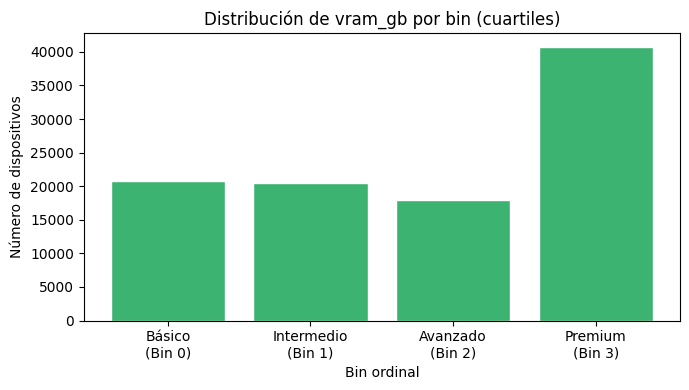

In [76]:
# Distribución por bin
bin_counts = compu_transf['vram_gb'].value_counts().sort_index()
labels = ['Básico\n(Bin 0)', 'Intermedio\n(Bin 1)',
          'Avanzado\n(Bin 2)', 'Premium\n(Bin 3)']

plt.figure(figsize=(7, 4))
plt.bar(range(4), bin_counts.values, color='mediumseagreen', edgecolor='white')
plt.xticks(range(4), labels)
plt.title('Distribución de vram_gb por bin (cuartiles)')
plt.xlabel('Bin ordinal')
plt.ylabel('Número de dispositivos')
plt.tight_layout()
plt.show()

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

### Análisis — Ejercicio 5

En los histogramas del ejercicio 2 se observa una barra prominente en 0 tanto en `charger_watts` como en `psu_watts`. Esto **no representa datos faltantes ni errores**: refleja que ambas variables son mutuamente excluyentes según el tipo de dispositivo.

- **`charger_watts`** registra la potencia del cargador externo, que **solo aplica a laptops**. Para un desktop este valor es 0 porque no tiene cargador portátil.
- **`psu_watts`** registra la potencia de la fuente de poder interna, que **solo aplica a desktops**. Para una laptop este valor es 0 porque no tiene PSU separada.

La solución es combinar ambas en una única columna `power_watts` que contenga el valor relevante para cada tipo de dispositivo, eliminando así la redundancia y la barra espuria en cero.

In [77]:
# Verificación de la exclusividad mutua
print("charger_watts = 0 por tipo de dispositivo:")
print(compu_transf[compu_transf['charger_watts'] == 0]['device_type'].value_counts())
print("\npsu_watts = 0 por tipo de dispositivo:")
print(compu_transf[compu_transf['psu_watts'] == 0]['device_type'].value_counts())

charger_watts = 0 por tipo de dispositivo:
device_type
Desktop    40156
Name: count, dtype: int64

psu_watts = 0 por tipo de dispositivo:
device_type
Laptop    59844
Name: count, dtype: int64


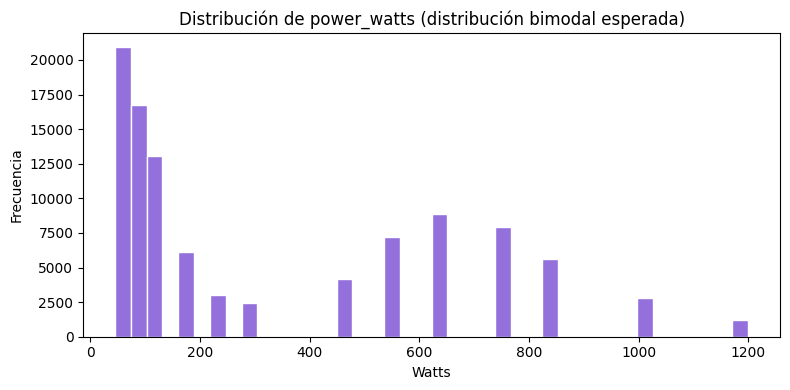

charger_watts y psu_watts eliminadas.
Forma resultante: (100000, 23)


In [78]:
# Combinar en power_watts
compu_transf['power_watts'] = np.where(
    compu_transf['device_type'].str.lower().str.contains('desktop'),
    compu_transf['psu_watts'],
    compu_transf['charger_watts']
)

# Histograma — verificar distribución bimodal
plt.figure(figsize=(8, 4))
plt.hist(compu_transf['power_watts'], bins=40, color='mediumpurple', edgecolor='white')
plt.title('Distribución de power_watts (distribución bimodal esperada)')
plt.xlabel('Watts')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Eliminar columnas originales
compu_transf.drop(columns=['charger_watts', 'psu_watts'], inplace=True)
print("charger_watts y psu_watts eliminadas.")
print(f"Forma resultante: {compu_transf.shape}")

6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

### Contexto — Ejercicio 6

El precio de las computadoras sigue una distribución con sesgo positivo: la mayoría de equipos se concentra en rangos medios-bajos, pero algunos de alta gama elevan la media. Muchos algoritmos de regresión asumen distribución aproximadamente normal en la variable objetivo. Transformarla reduce el impacto de outliers y mejora la estabilidad del entrenamiento.

Se comparan tres transformaciones:
- **Logarítmica** `ln(x)`: comprime fuertemente los valores grandes. Sencilla e interpretable.
- **Raíz cuadrada** `√x`: compresión más suave. Útil cuando el sesgo es moderado.
- **Box-Cox**: encuentra el exponente λ óptimo que maximiza la normalidad. Es la más flexible.

In [79]:
# Verificar que price > 0 (requerido por log y Box-Cox)
print(f"Valores de price <= 0: {(compu_transf['price'] <= 0).sum()}")

# Crear variables temporales con cada transformación
price_orig = compu_transf['price'].copy()
price_log  = np.log(price_orig)
price_sqrt = np.sqrt(price_orig)

pt_compare = PowerTransformer(method='box-cox', standardize=False)
price_bc   = pd.Series(
    pt_compare.fit_transform(price_orig.values.reshape(-1, 1)).flatten(),
    index=price_orig.index
)

Valores de price <= 0: 0


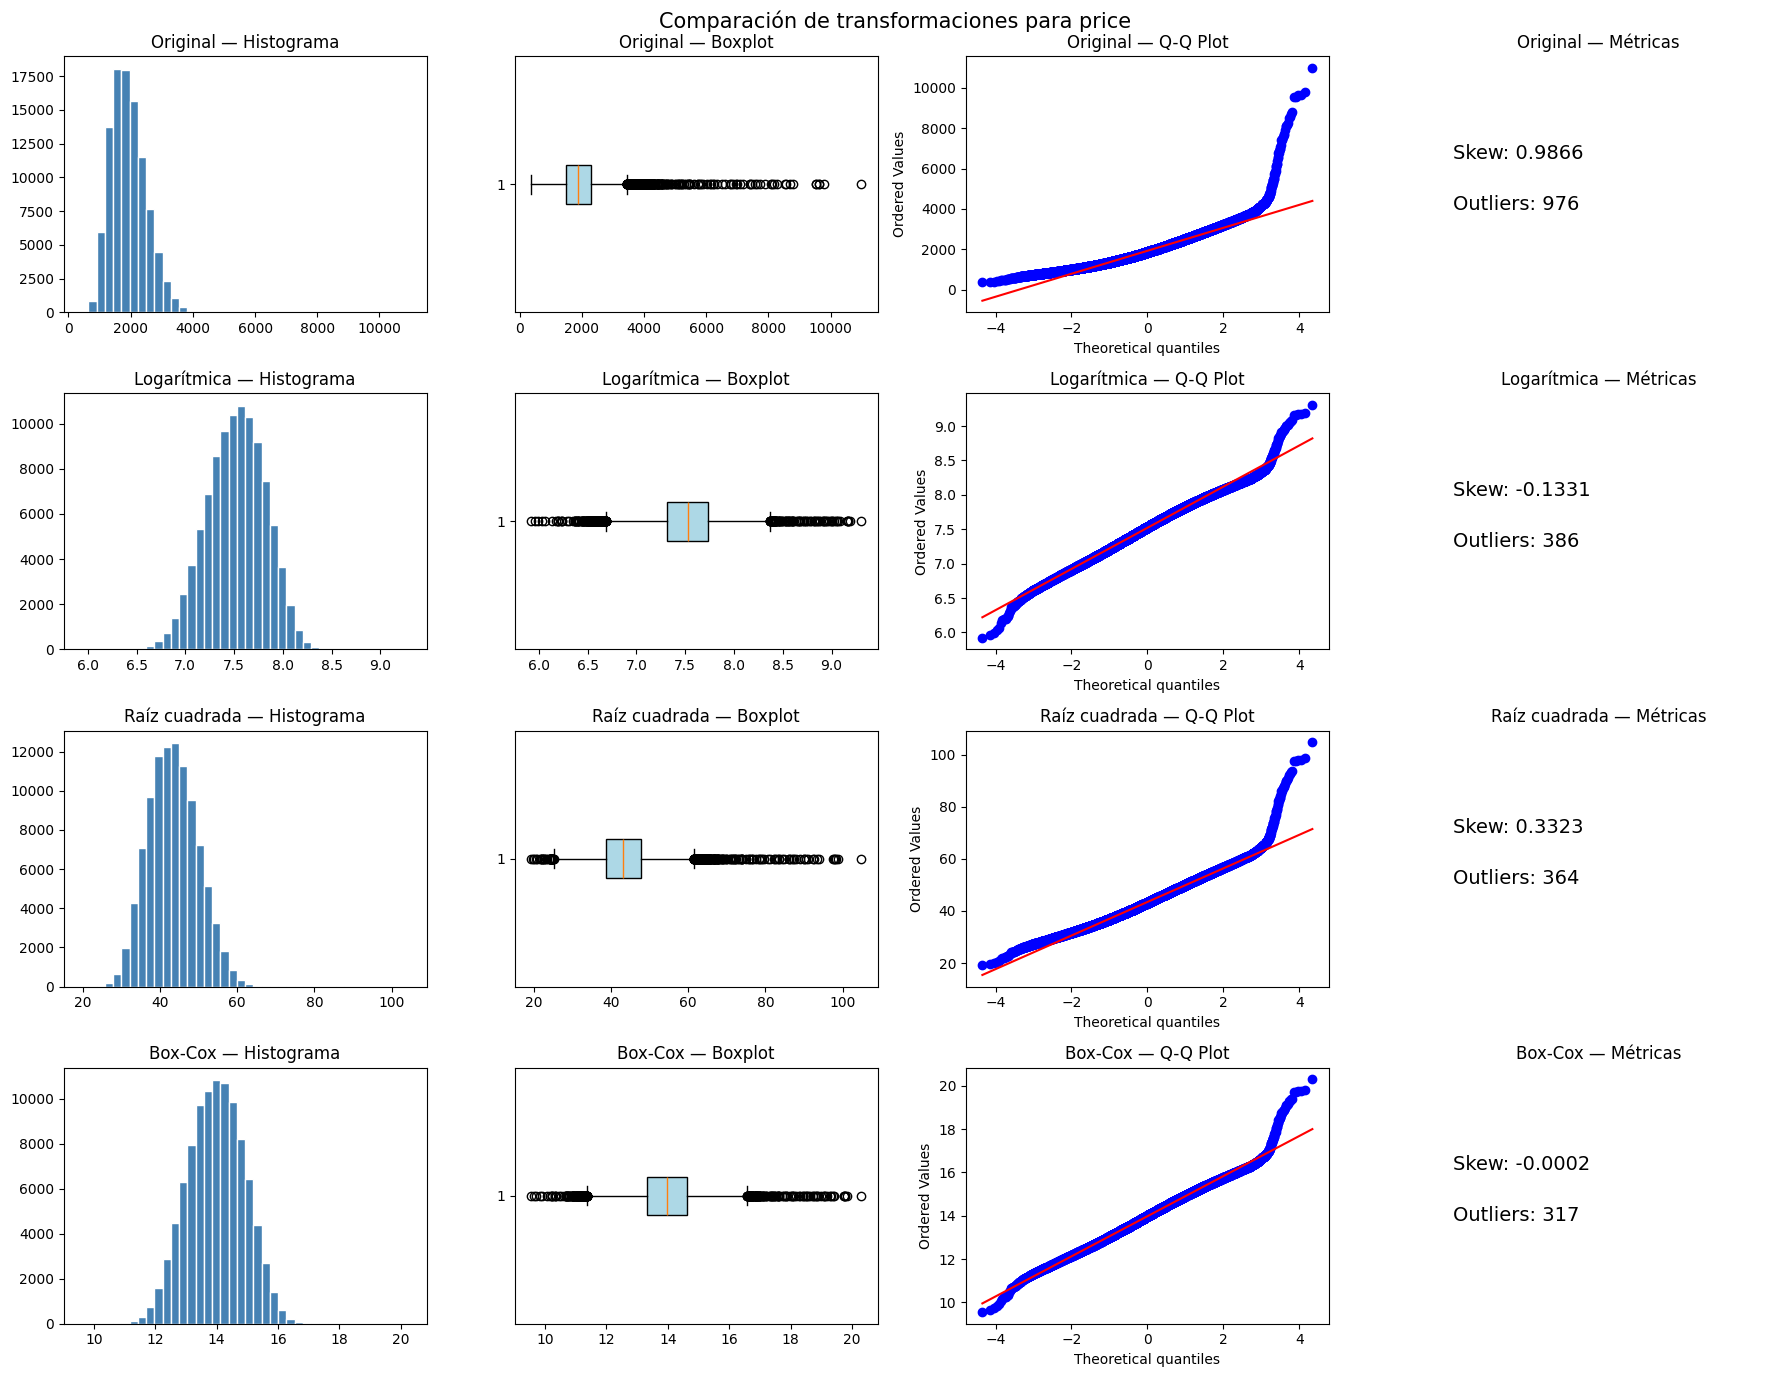

In [80]:
# Función de conteo de outliers (método IQR)
def count_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    mask = (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)
    return mask.sum()

# Comparación visual: histograma, boxplot, Q-Q plot, métricas
transformations = {
    'Original'      : price_orig,
    'Logarítmica'   : price_log,
    'Raíz cuadrada' : price_sqrt,
    'Box-Cox'       : price_bc,
}

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for i, (name, data) in enumerate(transformations.items()):
    axes[i][0].hist(data, bins=40, color='steelblue', edgecolor='white')
    axes[i][0].set_title(f'{name} — Histograma')

    axes[i][1].boxplot(data.dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[i][1].set_title(f'{name} — Boxplot')

    probplot(data.dropna(), dist="norm", plot=axes[i][2])
    axes[i][2].set_title(f'{name} — Q-Q Plot')

    skew_val = data.skew()
    outliers = count_outliers(data)
    axes[i][3].axis('off')
    axes[i][3].text(0.1, 0.6, f"Skew: {skew_val:.4f}", fontsize=14)
    axes[i][3].text(0.1, 0.4, f"Outliers: {outliers}", fontsize=14)
    axes[i][3].set_title(f'{name} — Métricas')

plt.suptitle('Comparación de transformaciones para price', fontsize=15)
plt.tight_layout()
plt.show()

In [81]:
# Resumen numérico comparativo
print(f"{'Transformación':<18} {'Skew':>12} {'Outliers':>12}")
print("-" * 44)
for name, data in transformations.items():
    print(f"{name:<18} {data.skew():>12.4f} {count_outliers(data):>12}")

Transformación             Skew     Outliers
--------------------------------------------
Original                 0.9866          976
Logarítmica             -0.1331          386
Raíz cuadrada            0.3323          364
Box-Cox                 -0.0002          317


### Decisión — Ejercicio 6

**Transformación seleccionada: Box-Cox**

Criterios de decisión observados al comparar las cuatro versiones:
- **Histograma**: Box-Cox produce la distribución más simétrica y acampanada.
- **Q-Q plot**: los puntos se ajustan mejor a la línea diagonal de normalidad teórica respecto al original, logarítmica y raíz cuadrada.
- **Skew**: Box-Cox obtiene el valor más cercano a 0 entre las cuatro opciones.
- **Outliers**: Box-Cox reduce el número de valores extremos al comprimir la cola derecha de forma óptima para estos datos.

Box-Cox es la transformación más flexible porque estima el parámetro λ que maximiza la normalidad para cada variable específica, algo que logaritmo (λ = 0) y raíz cuadrada (λ = 0.5) no pueden adaptar. Se aplica a las tres variables continuas: `weight_kg`, `power_watts` y `price`.

> *Nota: si al ejecutar el notebook la comparación revela que otra transformación logra un skew menor, se debe actualizar esta celda y el código siguiente con la transformación correspondiente.*

In [82]:
# Aplicar Box-Cox a las variables continuas
pt_weight = PowerTransformer(method='box-cox', standardize=False)
pt_power  = PowerTransformer(method='box-cox', standardize=False)
pt_price  = PowerTransformer(method='box-cox', standardize=False)

compu_transf['weight_kg']   = pt_weight.fit_transform(compu_transf[['weight_kg']])
compu_transf['power_watts'] = pt_power.fit_transform(compu_transf[['power_watts']])
compu_transf['price']       = pt_price.fit_transform(compu_transf[['price']])

print("Transformación aplicada. Skew post-transformación:")
for col in ['weight_kg', 'power_watts', 'price']:
    print(f"  {col}: skew = {compu_transf[col].skew():.4f}")

Transformación aplicada. Skew post-transformación:
  weight_kg: skew = 0.2137
  power_watts: skew = 0.0866
  price: skew = -0.0002


7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

### Contexto — Ejercicio 7

Las variables numéricas están en escalas muy distintas: `ram_gb` puede ir de 4 a 128, mientras `years_since_release` varía entre 0 y ~10. Algoritmos basados en distancias (KNN) o gradientes (regresión regularizada, redes neuronales) se sesgarían hacia las variables con valores más grandes. `MinMaxScaler` lleva todo al rango [0, 1] sin distorsionar la distribución.

In [83]:
num_features = compu_transf.select_dtypes(include='number').columns.tolist()
print(f"Variables a escalar ({len(num_features)}): {num_features}")

scaler = MinMaxScaler()
compu_transf[num_features] = scaler.fit_transform(compu_transf[num_features])

print("\nVerificación de rango tras escalado:")
print(compu_transf[num_features].agg(['min', 'max']))

Variables a escalar (13): ['cpu_tier', 'cpu_cores', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count', 'bluetooth', 'weight_kg', 'warranty_months', 'price', 'years_since_release', 'power_watts']

Verificación de rango tras escalado:
     cpu_tier  cpu_cores  gpu_tier  vram_gb  ram_gb  storage_gb  \
min       0.0        0.0       0.0      0.0     0.0         0.0   
max       1.0        1.0       1.0      1.0     1.0         1.0   

     storage_drive_count  bluetooth  weight_kg  warranty_months  price  \
min                  0.0        0.0        0.0              0.0    0.0   
max                  1.0        1.0        1.0              1.0    1.0   

     years_since_release  power_watts  
min                  0.0          0.0  
max                  1.0          1.0  


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

### Contexto — Ejercicio 8

`wifi` es categórica con orden natural: Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7. Cada estándar implica mayor velocidad y menor latencia, y ese orden sí impacta en el precio del dispositivo. Tratarla como ordinal preserva esa jerarquía; codificarla con OHE la perdería al tratarla como nominal. Se escala posteriormente a [0, 1] para mantener coherencia con el resto del dataframe.

In [84]:
# Verificar valores únicos presentes
print("Valores únicos en wifi:", sorted(compu_transf['wifi'].unique()))

# Codificación ordinal con orden explícito
wifi_order = [['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']]
ord_enc = OrdinalEncoder(categories=wifi_order,
                         handle_unknown='use_encoded_value',
                         unknown_value=-1)
compu_transf['wifi'] = ord_enc.fit_transform(compu_transf[['wifi']])

# Escalar a [0, 1]
wifi_scaler = MinMaxScaler()
compu_transf['wifi'] = wifi_scaler.fit_transform(compu_transf[['wifi']])

print("\nDistribución de wifi tras codificación y escalado:")
print(compu_transf['wifi'].value_counts().sort_index())
print(f"\nRango: [{compu_transf['wifi'].min():.2f}, {compu_transf['wifi'].max():.2f}]")

Valores únicos en wifi: ['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']

Distribución de wifi tras codificación y escalado:
wifi
0.000000    19926
0.333333    46149
0.666667    25923
1.000000     8002
Name: count, dtype: int64

Rango: [0.00, 1.00]


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

### Contexto — Ejercicio 9

`gpu_model` tiene alta cardinalidad (49 valores únicos). Si se aplicara One-Hot Encoding se generarían 48 columnas adicionales, la mayoría llenas de ceros ("maldición de la dimensionalidad"). Binary Encoding representa cada categoría con solo ⌈log₂(n)⌉ bits: para 49 modelos de GPU, OHE necesita 48 columnas; Binary Encoding solo 6. Se guarda en `bin_df` para integrarlo al final con el resto del dataframe.

In [85]:
bin_enc = BinaryEncoder(cols=['gpu_model'])
bin_df  = bin_enc.fit_transform(compu_transf[['gpu_model']])

print(f"Columnas originales:  1  (gpu_model)")
print(f"Columnas con BinaryEncoder: {bin_df.shape[1]}")
print("\nMuestra (primeras 5 filas):")
print(bin_df.head())

Columnas originales:  1  (gpu_model)
Columnas con BinaryEncoder: 6

Muestra (primeras 5 filas):
   gpu_model_0  gpu_model_1  gpu_model_2  gpu_model_3  gpu_model_4  \
0            0            0            0            0            0   
1            0            0            0            0            1   
2            0            0            0            0            1   
3            0            0            0            1            0   
4            0            0            0            1            0   

   gpu_model_5  
0            1  
1            0  
2            1  
3            0  
4            1  


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

### Contexto — Ejercicio 10

Las variables categóricas restantes son nominales sin orden natural y con cardinalidad manejable, por lo que se codifican con One-Hot Encoding. El parámetro `drop='first'` elimina una columna por variable para evitar la trampa de la multicolinealidad (k−1 columnas son suficientes para representar k categorías).

> **Nota sobre `bluetooth`**: su tipo en el CSV es `float64`, por lo que ya fue tratada como numérica y escalada en el ejercicio 7. No aparecerá como categórica en este paso.

In [86]:
# Columnas categóricas restantes (wifi ya es numérica; bluetooth es float)
cat_remaining = compu_transf.select_dtypes(include='object').columns.tolist()
print("Columnas a codificar con OHE:", cat_remaining)

Columnas a codificar con OHE: ['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand', 'gpu_model', 'storage_type', 'display_type']


In [87]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_array = ohe.fit_transform(compu_transf[cat_remaining])
ohe_df    = pd.DataFrame(ohe_array,
                         columns=ohe.get_feature_names_out(cat_remaining),
                         index=compu_transf.index)

print(f"Columnas generadas por OHE: {ohe_df.shape[1]}")

Columnas generadas por OHE: 83


In [88]:
# Eliminar columnas originales ya codificadas (gpu_model está dentro de cat_remaining)
# Se usa cat_remaining directamente para evitar duplicados en la lista de columnas a eliminar
compu_transf.drop(columns=cat_remaining, inplace=True)

# Combinar los tres dataframes
compu_final = pd.concat([compu_transf, bin_df, ohe_df], axis=1)

print(f"Forma del dataframe final: {compu_final.shape}")

Forma del dataframe final: (100000, 103)


In [89]:
# Verificación con describe()
desc = compu_final.describe()
print(desc.T[['min', 'max', 'mean']].to_string())

                            min  max      mean
cpu_tier                    0.0  1.0  0.430698
cpu_cores                   0.0  1.0  0.271489
gpu_tier                    0.0  1.0  0.398270
vram_gb                     0.0  1.0  0.595883
ram_gb                      0.0  1.0  0.233135
storage_gb                  0.0  1.0  0.168733
storage_drive_count         0.0  1.0  0.174993
wifi                        0.0  1.0  0.406670
bluetooth                   0.0  1.0  0.804331
weight_kg                   0.0  1.0  0.517032
warranty_months             0.0  1.0  0.283343
price                       0.0  1.0  0.411800
years_since_release         0.0  1.0  0.382736
power_watts                 0.0  1.0  0.499405
gpu_model_0                 0.0  1.0  0.118160
gpu_model_1                 0.0  1.0  0.224950
gpu_model_2                 0.0  1.0  0.381060
gpu_model_3                 0.0  1.0  0.482690
gpu_model_4                 0.0  1.0  0.525590
gpu_model_5                 0.0  1.0  0.686920
device_type_L

In [90]:
# Confirmar que no quedan columnas categóricas
cat_restantes = compu_final.select_dtypes(include='object').columns.tolist()
if cat_restantes:
    print(f"ATENCIÓN — columnas categóricas sin codificar: {cat_restantes}")
else:
    print("OK — todas las columnas son numéricas.")

# Confirmar escala [0, 1]
fuera_escala = [(c, desc[c]['min'], desc[c]['max'])
                for c in compu_final.columns
                if desc[c]['min'] < -0.01 or desc[c]['max'] > 1.01]
if fuera_escala:
    print("\nColumnas fuera de [0, 1]:")
    for c, mn, mx in fuera_escala:
        print(f"  {c}: min={mn:.4f}, max={mx:.4f}")
else:
    print("OK — todas las columnas están en el rango [0, 1].")

OK — todas las columnas son numéricas.
OK — todas las columnas están en el rango [0, 1].


---

**Declaración de uso de IA**

Anthropic. (2026). *Claude (claude-sonnet-4-6)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://claude.ai/

---